# A3TGCN

In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading.epidataloader import EpiDataLoader
from src.dataloading.gnndataloader import GNNDataLoader

from src.models.a3tgcn import A3TGCNModel

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from src.utils.constants import *


# epidata_nuts2 = GNNDataLoader('influenza', data_env, nuts_level='nuts2', min_date='2006-05-15',max_date='2020-06-01', include_population=True, periods = 12, prediction_horizon=4)
# epidata_nuts2.add_time_features()
# epidata_nuts2.log_transform_target()
# epidata_nuts2.set_splits()
# epidata_nuts2.normalize()
# epidata_nuts2.add_lagged_features(lags = range(2,3))
# epidata_nuts2.finalize()

# epidata_nuts2_id  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'identity_graph').construct_dataloaders()
# epidata_nuts2_bn  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_self0').construct_dataloaders()
# epidata_nuts2_gm1 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_dense').construct_dataloaders()
# epidata_nuts2_gm2 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_sparse').construct_dataloaders()


from src.dataloading.gnndataloader import GNNDataLoader
epidata_nuts2 = GNNDataLoader('influenza', data_env, nuts_level='nuts2', min_date='2006-05-15',max_date='2020-06-02', include_population=True, horizon_size = 1, horizon_leadtime = 2, sequence_length=12)
epidata_nuts2.add_time_features()
epidata_nuts2.log_transform_target()
epidata_nuts2.set_splits()
epidata_nuts2.normalize()
epidata_nuts2.add_lagged_features(lags = 1)
epidata_nuts2.finalize()

epidata_nuts2_id  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'identity_graph').construct_dataloaders()
epidata_nuts2_bn1  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_self0').construct_dataloaders()
epidata_nuts2_bn2  = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'boolean_neighbors_selfmn').construct_dataloaders()
epidata_nuts2_gm1 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_dense').construct_dataloaders()
epidata_nuts2_gm2 = epidata_nuts2.copy(deep=True).retrieve_graph(graphname = 'gravity_model_sparse').construct_dataloaders()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-02-06 (+14 weeks)
Dataloader temporal windowing: extending data collection from 2006-02-06 to 2005-10-31 (+14 weeks)
Dataloader temporal windowing: extending data collection from 2006-02-06 to 2005-10-31 (+14 weeks)
Dataloader temporal windowing: extending data collection from 2006-02-06 to 2005-10-31 (+14 weeks)
Dataloader temporal windowing: extending data collection from 2006-02-06 to 2005-10-31 (+14 weeks)
Dataloader temporal windowing: extending data collection from 2006-02-06 to 2005-10-31 (+14 weeks)


shape x: torch.Size([38, 4, 12])
shape unsqueezed x: torch.Size([1, 38, 4, 12])
shape h: torch.Size([1, 38, 32])
shape output: torch.Size([38, 4])

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=[38, 4, 12], y=[38, 4], edge_index=[2, 38], edge_weight=[38])
Epoch 1 train loss: 0.8014, val loss: 1.7452 ✓ (new best)
Epoch 2 train loss: 0.7738, val loss: 1.6114 ✓ (new best)
Epoch 3 train loss: 0.7321, val loss: 1.4875 ✓ (new best)
Epoch 4 train loss: 0.6903, val loss: 1.3686 ✓ (new best)
Epoch 5 train loss: 0.6520, val loss: 1.2400 ✓ (new best)
Epoch 6 train loss: 0.6217, val loss: 1.1551 ✓ (new best)
Epoch 7 train loss: 0.5930, val loss: 1.0821 ✓ (new best)
Epoch 8 train loss: 0.5692, val loss: 1.0211 ✓ (new best)
Epoch 9 train loss: 0.5491, val loss: 0.9706 ✓ (new best)
Epoch 10 train loss: 0.5327, val loss: 0.9292 ✓ (new best)
Epoch 11 train loss

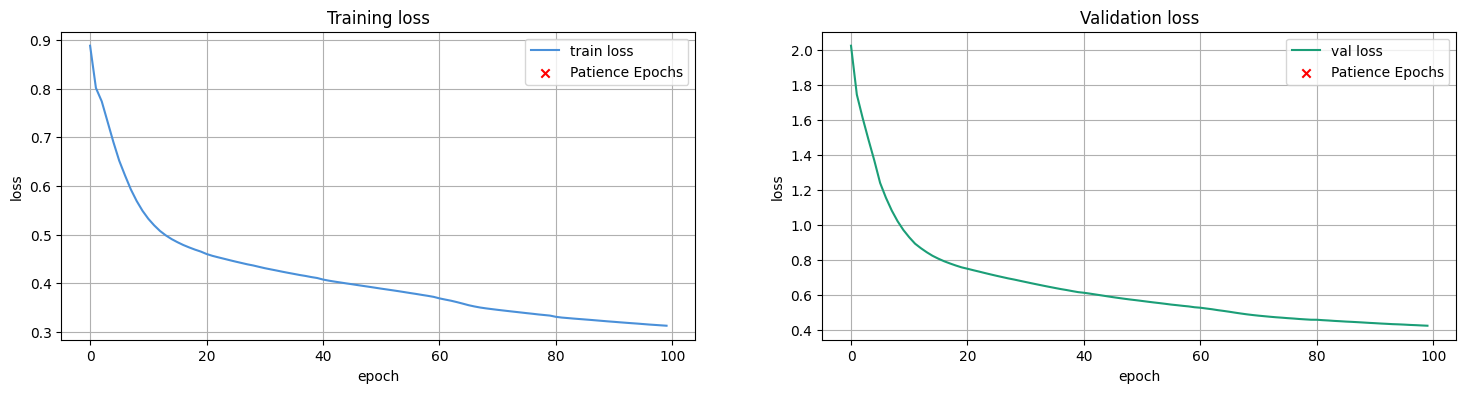

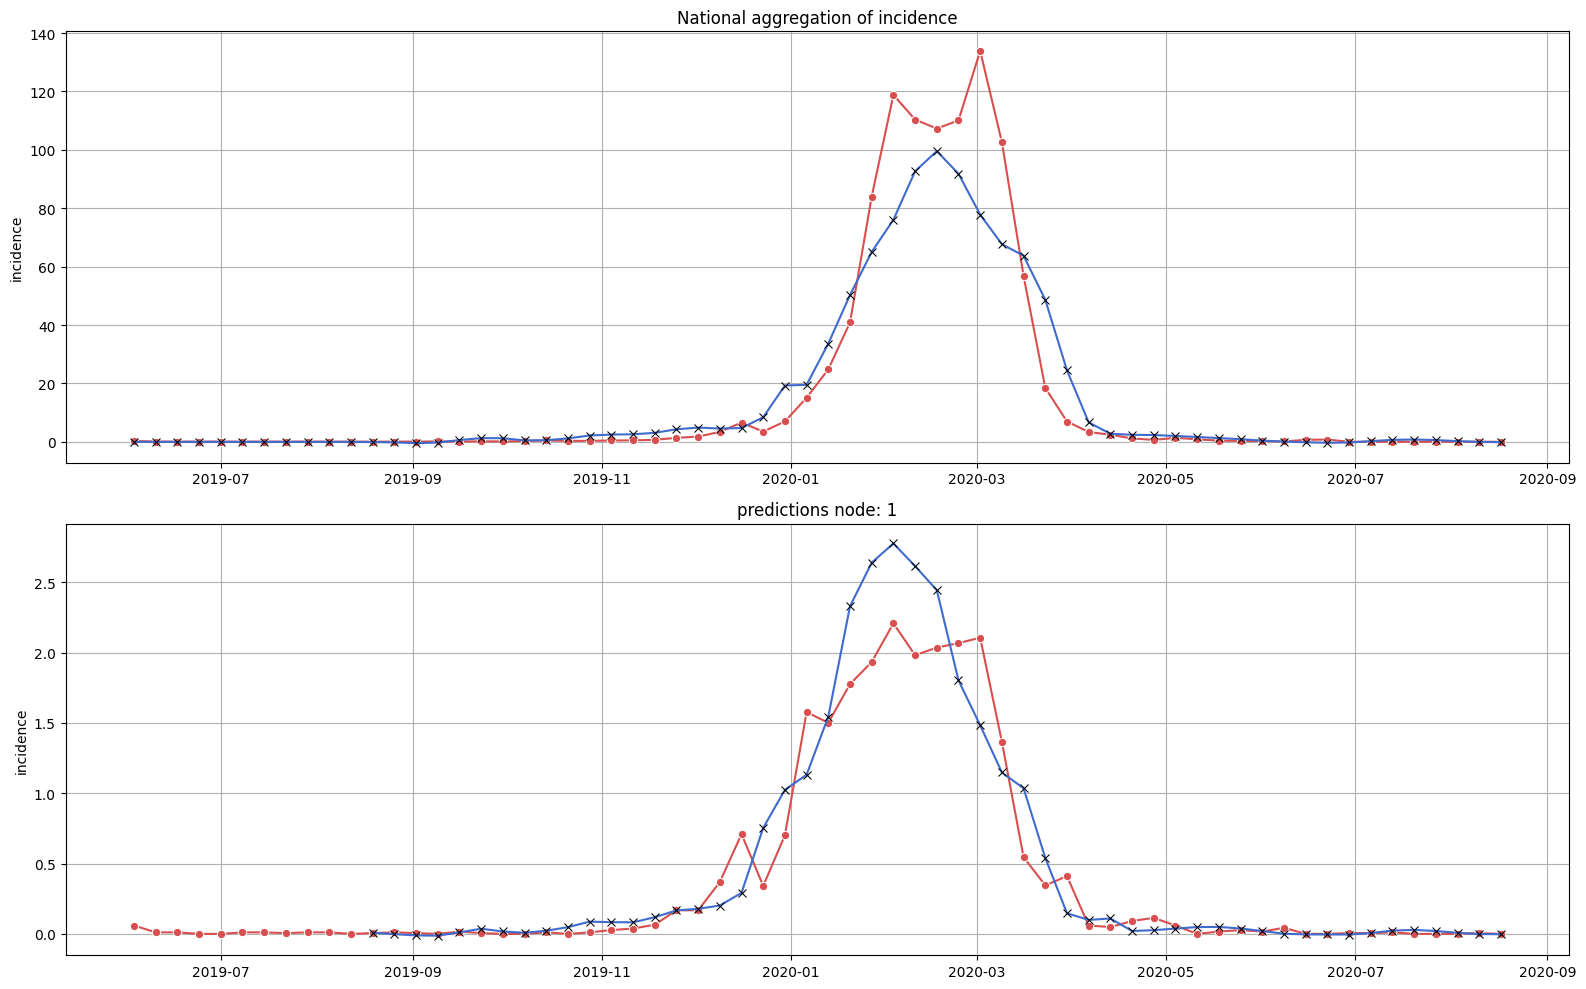

shape x: torch.Size([38, 4, 12])
shape unsqueezed x: torch.Size([1, 38, 4, 12])
shape h: torch.Size([1, 38, 32])
shape output: torch.Size([38, 4])

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=[38, 4, 12], y=[38, 4], edge_index=[2, 172], edge_weight=[172])
Epoch 1 train loss: 0.8132, val loss: 1.6946 ✓ (new best)
Epoch 2 train loss: 0.7974, val loss: 1.5985 ✓ (new best)
Epoch 3 train loss: 0.7698, val loss: 1.5215 ✓ (new best)
Epoch 4 train loss: 0.7382, val loss: 1.4397 ✓ (new best)
Epoch 5 train loss: 0.7059, val loss: 1.3534 ✓ (new best)
Epoch 6 train loss: 0.6737, val loss: 1.2738 ✓ (new best)
Epoch 7 train loss: 0.6444, val loss: 1.1971 ✓ (new best)
Epoch 8 train loss: 0.6192, val loss: 1.1328 ✓ (new best)
Epoch 9 train loss: 0.5974, val loss: 1.0776 ✓ (new best)
Epoch 10 train loss: 0.5784, val loss: 1.0308 ✓ (new best)
Epoch 11 train lo

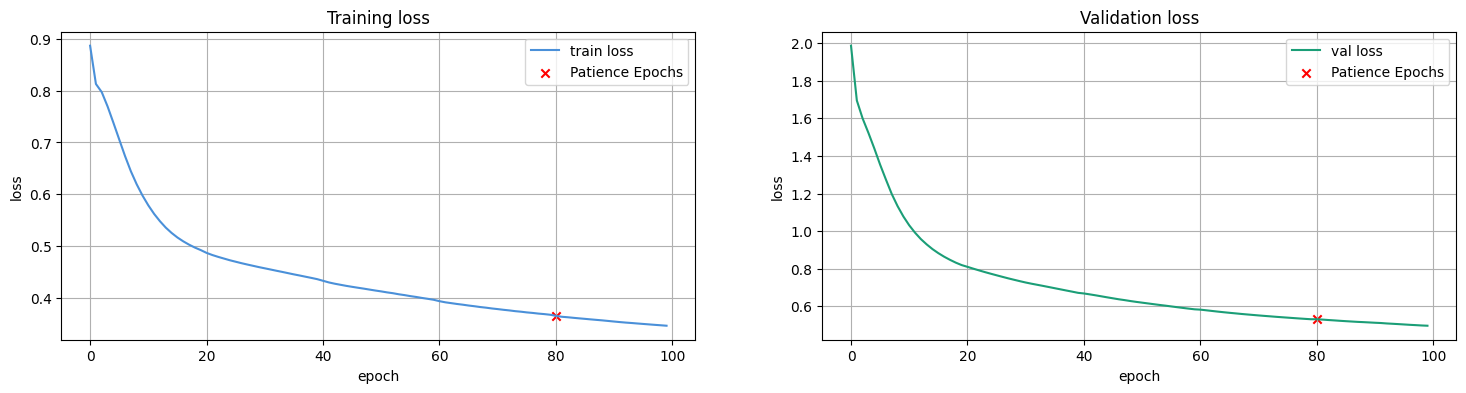

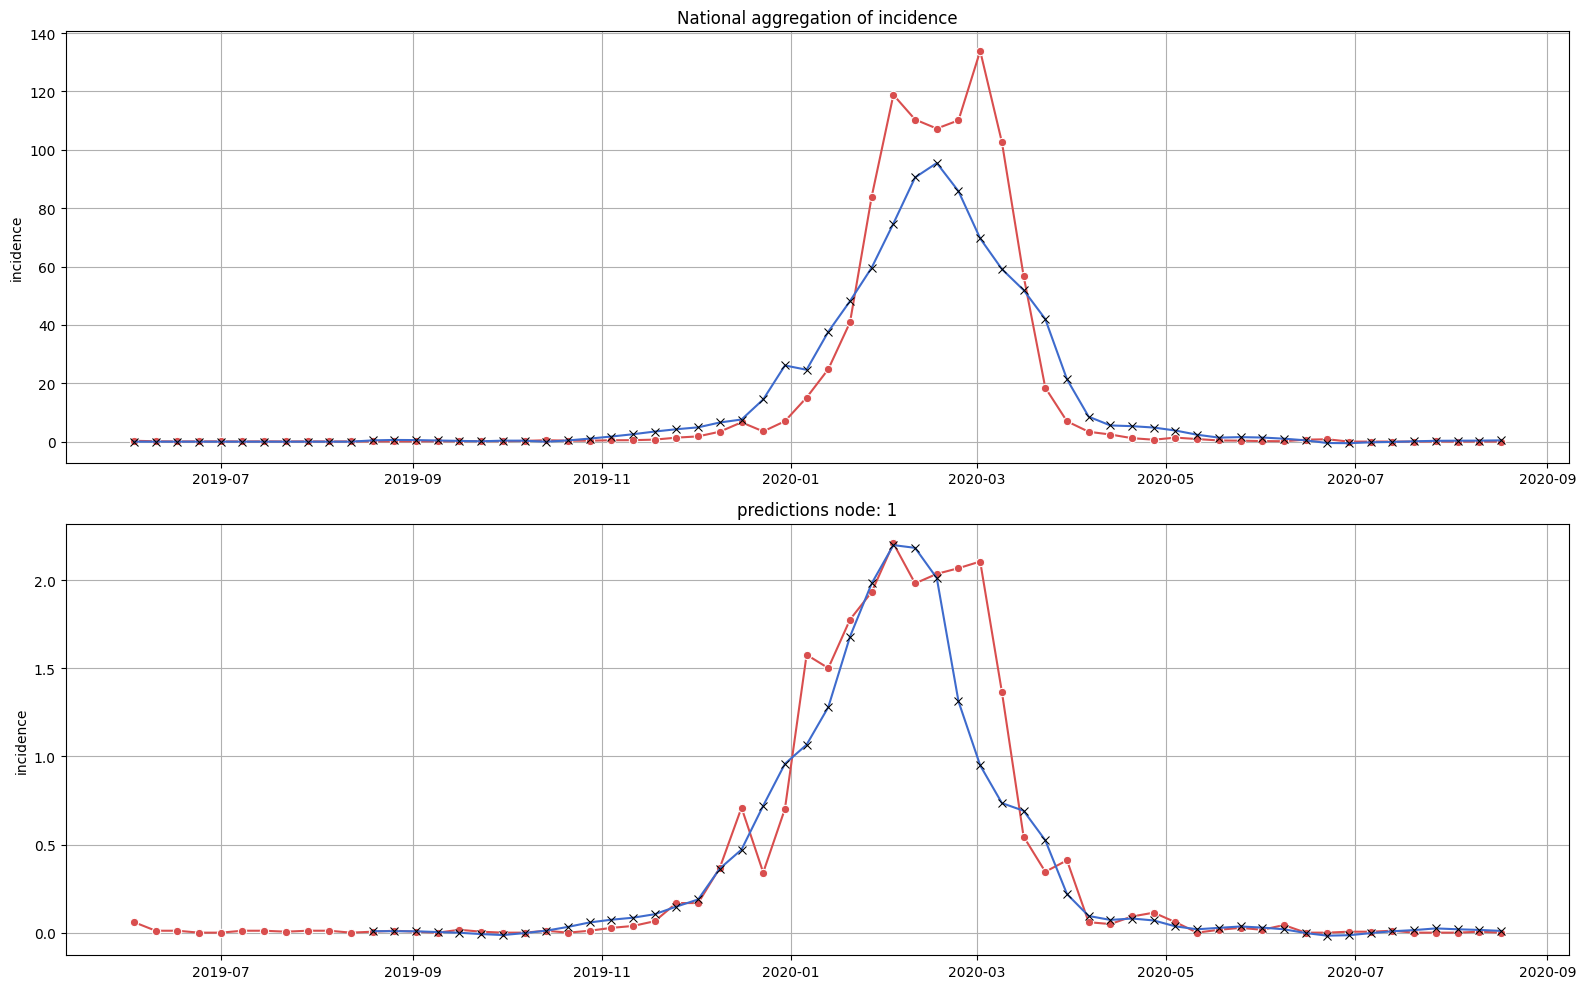

shape x: torch.Size([38, 4, 12])
shape unsqueezed x: torch.Size([1, 38, 4, 12])
shape h: torch.Size([1, 38, 32])
shape output: torch.Size([38, 4])

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=[38, 4, 12], y=[38, 4], edge_index=[2, 544], edge_weight=[544])
Epoch 1 train loss: 0.8105, val loss: 1.7505 ✓ (new best)
Epoch 2 train loss: 0.7731, val loss: 1.6040 ✓ (new best)
Epoch 3 train loss: 0.7242, val loss: 1.4790 ✓ (new best)
Epoch 4 train loss: 0.6749, val loss: 1.3617 ✓ (new best)
Epoch 5 train loss: 0.6337, val loss: 1.2621 ✓ (new best)
Epoch 6 train loss: 0.6031, val loss: 1.1823 ✓ (new best)
Epoch 7 train loss: 0.5810, val loss: 1.1201 ✓ (new best)
Epoch 8 train loss: 0.5645, val loss: 1.0710 ✓ (new best)
Epoch 9 train loss: 0.5518, val loss: 1.0324 ✓ (new best)
Epoch 10 train loss: 0.5413, val loss: 1.0003 ✓ (new best)
Epoch 11 train lo

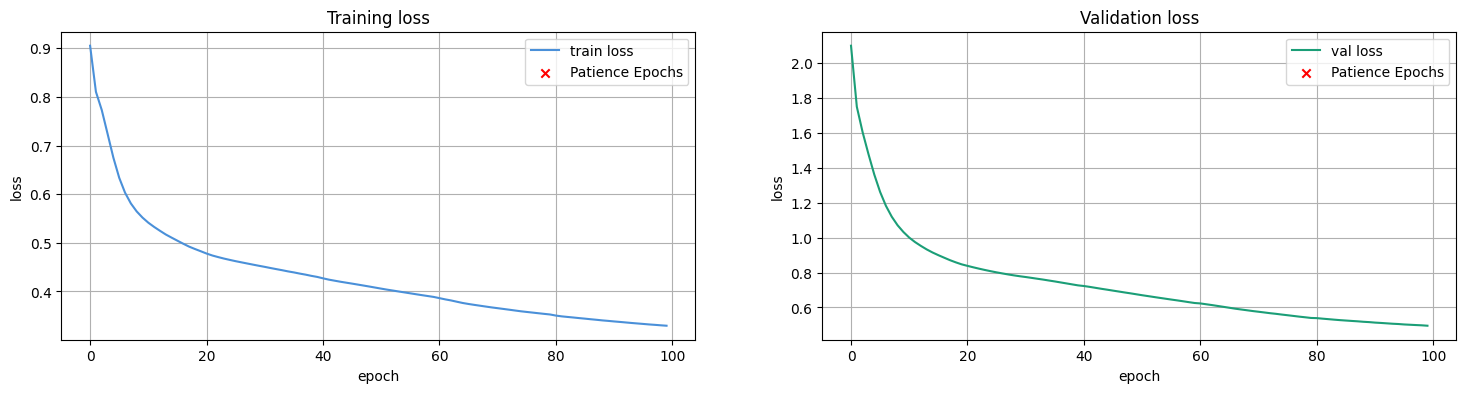

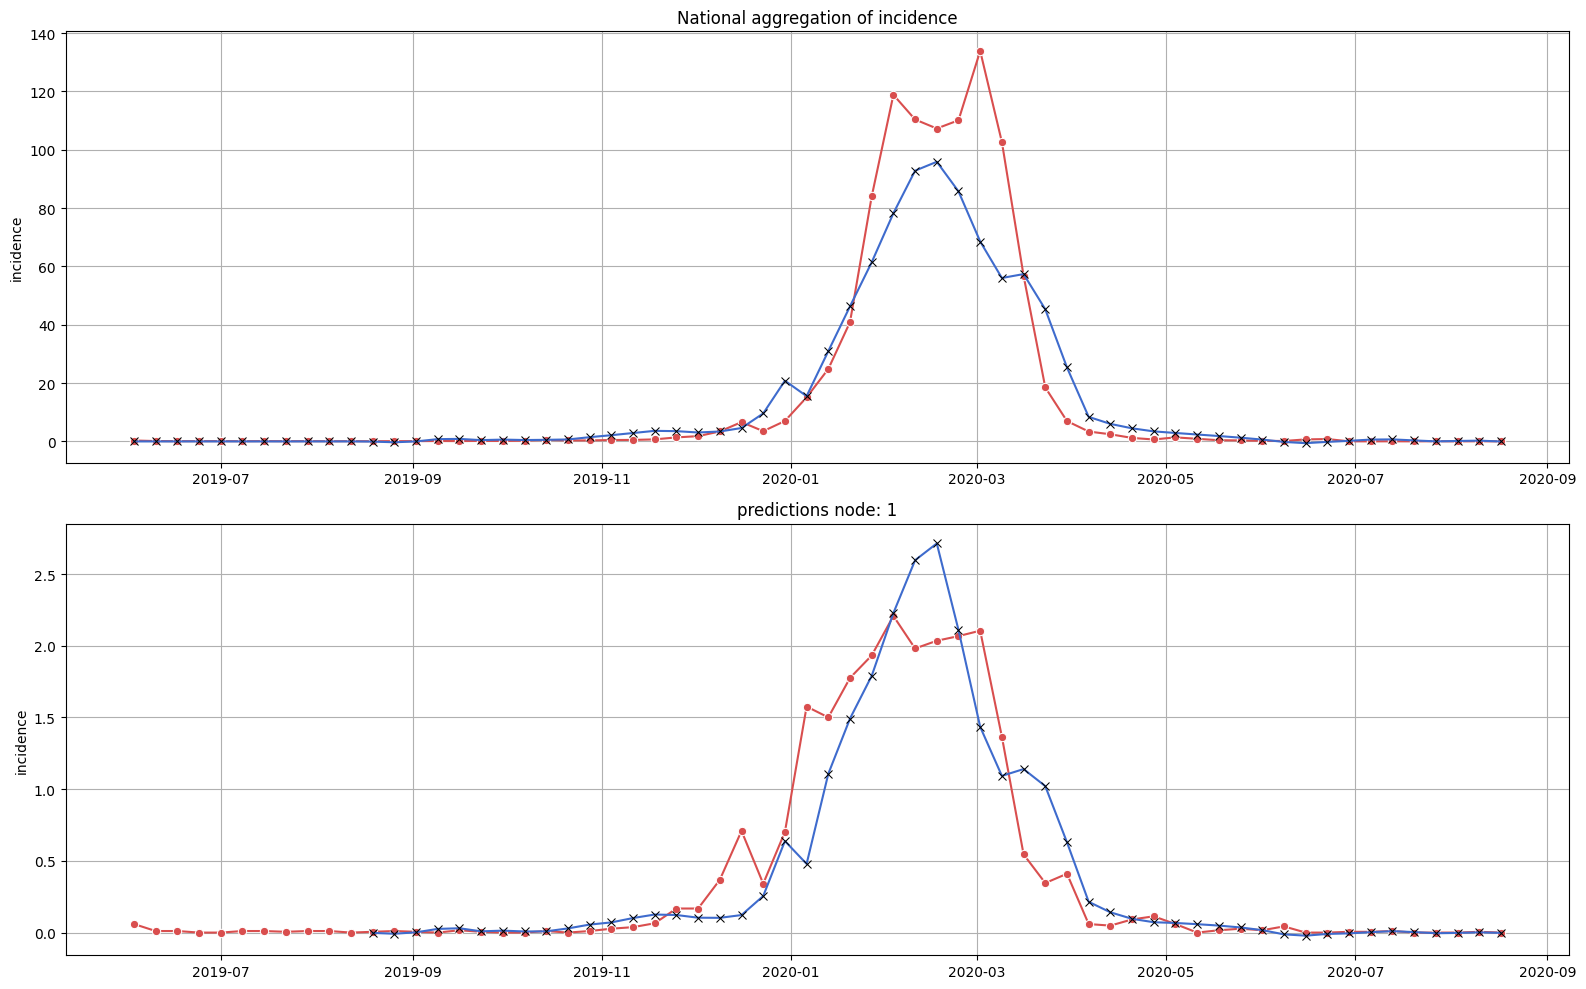

shape x: torch.Size([38, 4, 12])
shape unsqueezed x: torch.Size([1, 38, 4, 12])
shape h: torch.Size([1, 38, 32])
shape output: torch.Size([38, 4])

🧪 Snapshot 0 validation summary:
➡️  Predicted shape: torch.Size([38, 4])
➡️  Ground truth shape: torch.Size([38, 4])
✅ Snapshot ran successfully
Dataloader Snapshot: GraphDataLoaderEntry(x=[38, 4, 12], y=[38, 4], edge_index=[2, 224], edge_weight=[224])
Epoch 1 train loss: 0.8074, val loss: 1.5661 ✓ (new best)
Epoch 2 train loss: 0.7842, val loss: 1.4672 ✓ (new best)
Epoch 3 train loss: 0.7487, val loss: 1.3797 ✓ (new best)
Epoch 4 train loss: 0.7131, val loss: 1.2958 ✓ (new best)
Epoch 5 train loss: 0.6782, val loss: 1.2162 ✓ (new best)
Epoch 6 train loss: 0.6480, val loss: 1.1457 ✓ (new best)
Epoch 7 train loss: 0.6227, val loss: 1.0856 ✓ (new best)
Epoch 8 train loss: 0.6014, val loss: 1.0351 ✓ (new best)
Epoch 9 train loss: 0.5834, val loss: 0.9925 ✓ (new best)
Epoch 10 train loss: 0.5675, val loss: 0.9562 ✓ (new best)
Epoch 11 train lo

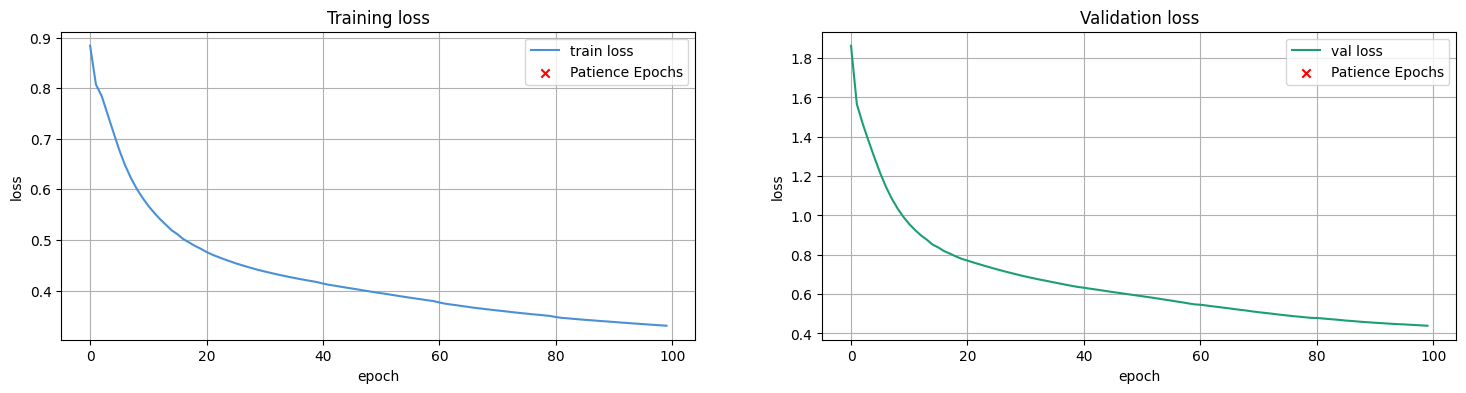

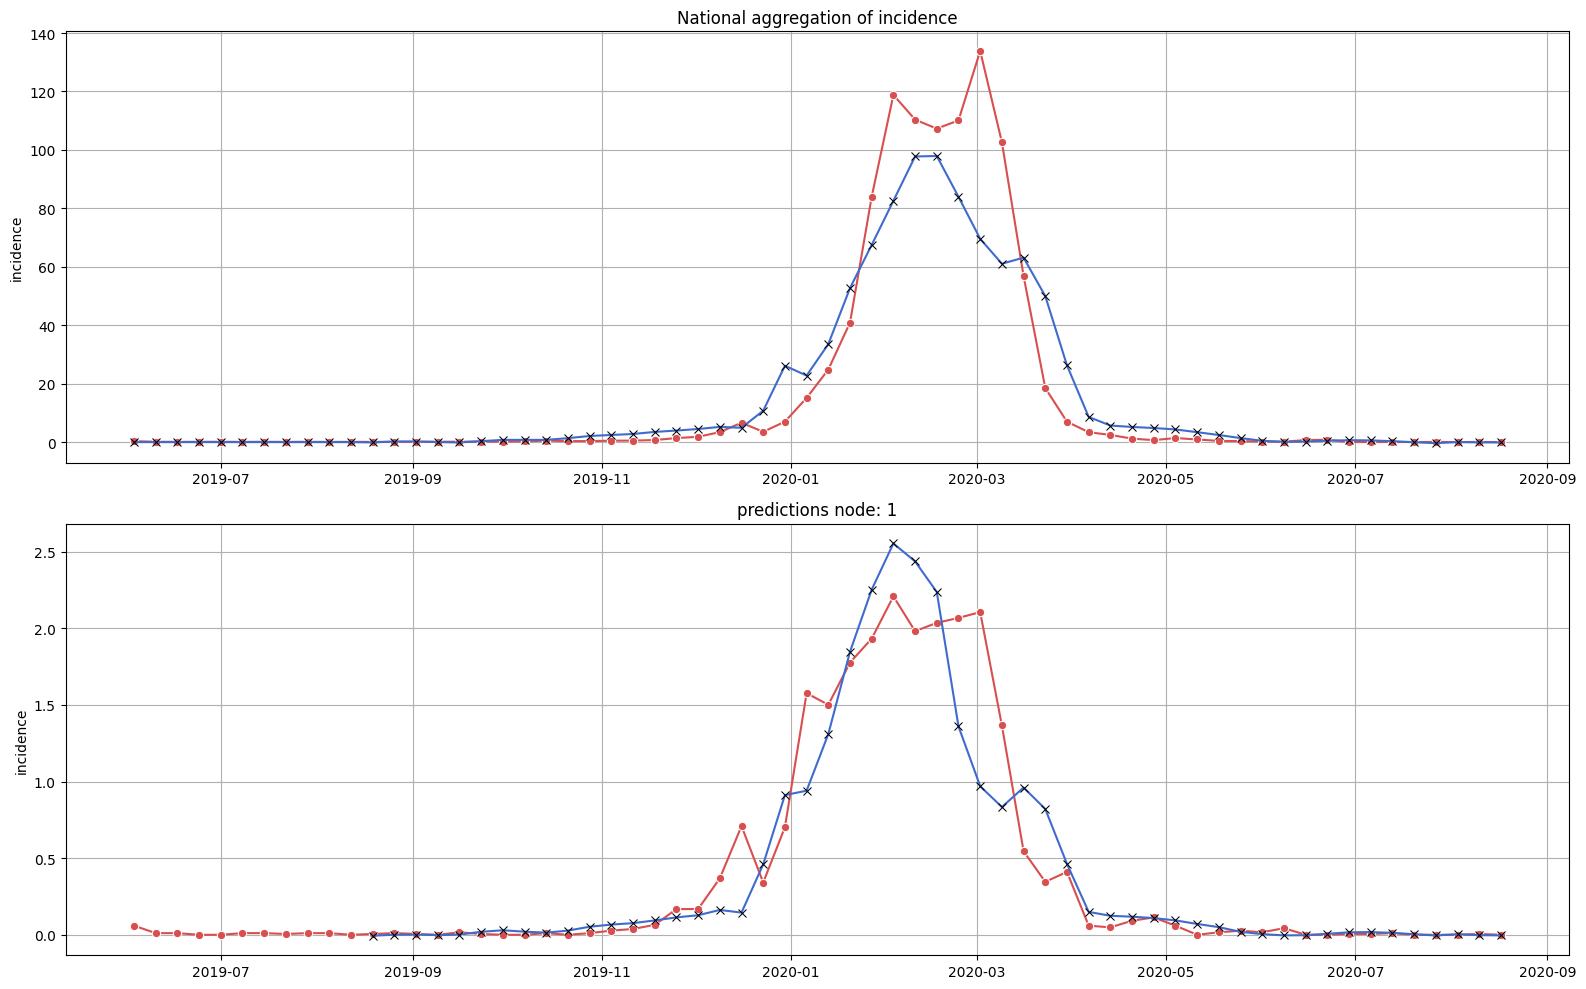

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 1'}, ylabel='incidence'>],
       dtype=object))

In [ ]:
n_epochs = 100
lr       = 0.0005

ml2_id = A3TGCNModel(name = f'a3tgcn-identity_graph', dataloader=epidata_nuts2_id)
ml2_id.set_model_hparams()
ml2_id.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_id.run_snapshot(debug=True)
ml2_id.train(verbose=2)
ml2_id.forecast()
ml2_id.show_forecasts(dataset='test', target_h = 0)

ml2_bn = A3TGCNModel(name = f'a3tgcn-boolean_neighbors', dataloader=epidata_nuts2_bn1)
ml2_bn.set_model_hparams()
ml2_bn.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_bn.run_snapshot(debug=True)
ml2_bn.train(verbose=2)
ml2_bn.forecast()
ml2_bn.show_forecasts(dataset='test', target_h = 0)


ml2_bn2 = A3TGCNModel(name = f'a3tgcn-boolean_neighbors 2', dataloader=epidata_nuts2_bn1)
ml2_bn2.set_model_hparams()
ml2_bn2.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_bn2.run_snapshot(debug=True)
ml2_bn2.train(verbose=2)
ml2_bn2.forecast()
ml2_bn2.show_forecasts(dataset='test', target_h = 0)

ml2_gm1 = A3TGCNModel(name = f'a3tgcn-gravity1', dataloader=epidata_nuts2_gm1)
ml2_gm1.set_model_hparams()
ml2_gm1.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_gm1.run_snapshot(debug=True)
ml2_gm1.train(verbose=2)
ml2_gm1.forecast()
ml2_gm1.show_forecasts(dataset='test', target_h = 0)

ml2_gm2 = A3TGCNModel(name = f'a3tgcn-gravity2', dataloader=epidata_nuts2_gm2)
ml2_gm2.set_model_hparams()
ml2_gm2.set_global_hparams(lr = lr, n_epochs=n_epochs, scheduler_kwargs={'step_size':20, 'gamma':0.95}, min_delta = 0.00001, loss = 'mse')
ml2_gm2.run_snapshot(debug=True)
ml2_gm2.train(verbose=2)
ml2_gm2.forecast()
ml2_gm2.show_forecasts(dataset='test', target_h = 0)